# YOLO11n 음식 탐지 학습 — Google Drive 데이터 직접 사용

이 노트북은 Google Drive의 다음 데이터셋 구조를 그대로 사용합니다.

```text
MyDrive/
└── training/
    └── yolo_food_detection/
        ├── images/
        │   ├── train/
        │   └── val/
        ├── labels/
        │   ├── train/
        │   └── val/
        ├── dataset.yaml
        └── dataset_audit.txt
```

주요 처리 과정:

1. Google Drive 마운트
2. 실제 폴더와 파일 검사
3. 이미지와 라벨의 1:1 대응 검사
4. YOLO 라벨 형식 검사
5. 코랩용 `dataset.yaml` 자동 생성
6. YOLO11n 학습
7. 검증 평가
8. 예측 결과 시각화
9. `best.pt`와 결과를 Google Drive에 저장

> 기존 Drive의 `dataset.yaml`에는 Windows 경로가 들어 있을 수 있으므로, 원본 파일을 수정하지 않고 코랩 전용 YAML을 `/content`에 생성합니다.


## 1. 런타임 설정

Colab 상단 메뉴에서 다음을 선택하세요.

```text
런타임 → 런타임 유형 변경 → 하드웨어 가속기 → T4 GPU
```

CPU에서도 실행할 수 있지만 학습 시간이 크게 늘어납니다.


In [1]:
# Ultralytics 설치
%pip install -q -U ultralytics pyyaml

print("설치 완료")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.5 MB/s eta 0:00:00
설치 완료


## 2. Google Drive 마운트 및 경로 설정

In [2]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# 사용자의 실제 Google Drive 데이터셋 경로
DRIVE_DATASET_ROOT = Path(
    "/content/drive/MyDrive/training/yolo_food_detection"
)

# 학습 결과가 저장될 Google Drive 경로
DRIVE_RUNS_ROOT = Path(
    "/content/drive/MyDrive/training/yolo_food_detection/runs"
)

# 코랩 로컬 임시 경로
LOCAL_DATASET_ROOT = Path("/content/yolo_food_detection")
COLAB_YAML_PATH = Path("/content/yolo_food_detection_colab.yaml")

print("Drive 데이터셋:", DRIVE_DATASET_ROOT)
print("Drive 결과 경로:", DRIVE_RUNS_ROOT)


Mounted at /content/drive
Drive 데이터셋: /content/drive/MyDrive/training/yolo_food_detection
Drive 결과 경로: /content/drive/MyDrive/training/yolo_food_detection/runs


## 3. 데이터셋 폴더 구조 검사

In [4]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# ==========================================================
# Google Drive 데이터셋 경로
# ==========================================================

DRIVE_DATASET_ROOT = Path(
    "/content/drive/MyDrive/final_1_team/apps/api/food-image-cleanup-pipeline/data/training/yolo_food_detection"
)

# images
TRAIN_IMAGE_DIR = DRIVE_DATASET_ROOT / "images/train"
VAL_IMAGE_DIR = DRIVE_DATASET_ROOT / "images/val"

# labels
TRAIN_LABEL_DIR = DRIVE_DATASET_ROOT / "labels/train"
VAL_LABEL_DIR = DRIVE_DATASET_ROOT / "labels/val"

# 원본 dataset.yaml
DATASET_YAML = DRIVE_DATASET_ROOT / "dataset.yaml"

# 학습 결과 저장 위치
DRIVE_RUNS_ROOT = DRIVE_DATASET_ROOT / "runs"

# 코랩에서 사용할 임시 dataset.yaml
COLAB_YAML_PATH = Path("/content/yolo_food_detection_colab.yaml")

print("=" * 60)
print("Dataset Root :", DRIVE_DATASET_ROOT)
print("Train Images :", TRAIN_IMAGE_DIR)
print("Val Images   :", VAL_IMAGE_DIR)
print("Train Labels :", TRAIN_LABEL_DIR)
print("Val Labels   :", VAL_LABEL_DIR)
print("Dataset YAML :", DATASET_YAML)
print("Runs Folder  :", DRIVE_RUNS_ROOT)
print("=" * 60)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Root : /content/drive/MyDrive/final_1_team/apps/api/food-image-cleanup-pipeline/data/training/yolo_food_detection
Train Images : /content/drive/MyDrive/final_1_team/apps/api/food-image-cleanup-pipeline/data/training/yolo_food_detection/images/train
Val Images   : /content/drive/MyDrive/final_1_team/apps/api/food-image-cleanup-pipeline/data/training/yolo_food_detection/images/val
Train Labels : /content/drive/MyDrive/final_1_team/apps/api/food-image-cleanup-pipeline/data/training/yolo_food_detection/labels/train
Val Labels   : /content/drive/MyDrive/final_1_team/apps/api/food-image-cleanup-pipeline/data/training/yolo_food_detection/labels/val
Dataset YAML : /content/drive/MyDrive/final_1_team/apps/api/food-image-cleanup-pipeline/data/training/yolo_food_detection/dataset.yaml
Runs Folder  : /content/drive/MyDrive/final_1_team/apps/api/food-image-cleanup

## 4. 데이터셋 검사

다음 내용을 검사합니다.

- 이미지 개수
- 라벨 개수
- 이미지와 라벨 파일명의 대응
- 라벨 한 줄이 `class x_center y_center width height` 형식인지
- 좌표가 0~1 범위인지
- 클래스 ID가 유효한지


In [5]:
from collections import Counter
from pathlib import Path

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
NUM_CLASSES = 1


def collect_images(directory: Path) -> list[Path]:
    return sorted(
        path for path in directory.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def collect_labels(directory: Path) -> list[Path]:
    return sorted(directory.rglob("*.txt"))


def validate_label_file(label_path: Path, num_classes: int) -> list[str]:
    errors = []

    try:
        lines = label_path.read_text(
            encoding="utf-8",
            errors="replace",
        ).splitlines()
    except Exception as exc:
        return [f"파일 읽기 실패: {exc}"]

    for line_number, raw_line in enumerate(lines, start=1):
        line = raw_line.strip()

        # 객체가 없는 이미지의 빈 라벨 파일은 허용
        if not line:
            continue

        parts = line.split()

        if len(parts) != 5:
            errors.append(
                f"{line_number}행: 값이 {len(parts)}개입니다. "
                "YOLO Detection 라벨은 5개여야 합니다."
            )
            continue

        try:
            class_id_float, x, y, width, height = map(float, parts)
        except ValueError:
            errors.append(f"{line_number}행: 숫자로 변환할 수 없습니다.")
            continue

        class_id = int(class_id_float)

        if class_id_float != class_id:
            errors.append(f"{line_number}행: 클래스 ID가 정수가 아닙니다.")

        if not 0 <= class_id < num_classes:
            errors.append(
                f"{line_number}행: 클래스 ID {class_id}가 "
                f"0~{num_classes - 1} 범위를 벗어났습니다."
            )

        coordinates = {
            "x_center": x,
            "y_center": y,
            "width": width,
            "height": height,
        }

        for name, value in coordinates.items():
            if not 0.0 <= value <= 1.0:
                errors.append(
                    f"{line_number}행: {name}={value}가 0~1 범위를 벗어났습니다."
                )

        if width <= 0 or height <= 0:
            errors.append(
                f"{line_number}행: width와 height는 0보다 커야 합니다."
            )

    return errors


def inspect_split(split: str) -> dict:
    image_dir = DRIVE_DATASET_ROOT / f"images/{split}"
    label_dir = DRIVE_DATASET_ROOT / f"labels/{split}"

    images = collect_images(image_dir)
    labels = collect_labels(label_dir)

    image_stems = {path.stem for path in images}
    label_stems = {path.stem for path in labels}

    missing_labels = sorted(image_stems - label_stems)
    orphan_labels = sorted(label_stems - image_stems)

    invalid_labels = {}
    class_counts = Counter()
    box_count = 0
    empty_label_count = 0

    for label_path in labels:
        errors = validate_label_file(label_path, NUM_CLASSES)

        if errors:
            invalid_labels[str(label_path)] = errors

        lines = [
            line.strip()
            for line in label_path.read_text(
                encoding="utf-8",
                errors="replace",
            ).splitlines()
            if line.strip()
        ]

        if not lines:
            empty_label_count += 1

        for line in lines:
            parts = line.split()
            if len(parts) == 5:
                try:
                    class_id = int(float(parts[0]))
                    class_counts[class_id] += 1
                    box_count += 1
                except ValueError:
                    pass

    return {
        "split": split,
        "image_count": len(images),
        "label_count": len(labels),
        "box_count": box_count,
        "empty_label_count": empty_label_count,
        "missing_labels": missing_labels,
        "orphan_labels": orphan_labels,
        "invalid_labels": invalid_labels,
        "class_counts": dict(class_counts),
    }


reports = {
    split: inspect_split(split)
    for split in ("train", "val")
}

for split, report in reports.items():
    print(f"\n===== {split.upper()} =====")
    print("이미지 수:", report["image_count"])
    print("라벨 수:", report["label_count"])
    print("Bounding Box 수:", report["box_count"])
    print("빈 라벨 파일 수:", report["empty_label_count"])
    print("클래스별 Box 수:", report["class_counts"])
    print("라벨이 없는 이미지 수:", len(report["missing_labels"]))
    print("이미지가 없는 라벨 수:", len(report["orphan_labels"]))
    print("형식 오류 라벨 수:", len(report["invalid_labels"]))

    if report["missing_labels"][:10]:
        print("라벨 없는 이미지 예시:", report["missing_labels"][:10])

    if report["orphan_labels"][:10]:
        print("이미지 없는 라벨 예시:", report["orphan_labels"][:10])

    if report["invalid_labels"]:
        first_path, first_errors = next(iter(report["invalid_labels"].items()))
        print("첫 번째 오류 파일:", first_path)
        print("오류 내용:", first_errors[:10])


fatal_errors = []

for split, report in reports.items():
    if report["image_count"] == 0:
        fatal_errors.append(f"{split}: 이미지가 없습니다.")

    if report["label_count"] == 0:
        fatal_errors.append(f"{split}: 라벨이 없습니다.")

    if report["missing_labels"]:
        fatal_errors.append(
            f"{split}: 라벨이 없는 이미지가 "
            f"{len(report['missing_labels'])}개 있습니다."
        )

    if report["orphan_labels"]:
        fatal_errors.append(
            f"{split}: 이미지가 없는 라벨이 "
            f"{len(report['orphan_labels'])}개 있습니다."
        )

    if report["invalid_labels"]:
        fatal_errors.append(
            f"{split}: 형식 오류 라벨이 "
            f"{len(report['invalid_labels'])}개 있습니다."
        )

if fatal_errors:
    raise RuntimeError(
        "데이터셋 검사를 통과하지 못했습니다:\n"
        + "\n".join(fatal_errors)
    )

print("\n모든 데이터셋 검사를 통과했습니다.")



===== TRAIN =====
이미지 수: 878
라벨 수: 878
Bounding Box 수: 878
빈 라벨 파일 수: 0
클래스별 Box 수: {0: 878}
라벨이 없는 이미지 수: 0
이미지가 없는 라벨 수: 0
형식 오류 라벨 수: 0

===== VAL =====
이미지 수: 158
라벨 수: 158
Bounding Box 수: 158
빈 라벨 파일 수: 0
클래스별 Box 수: {0: 158}
라벨이 없는 이미지 수: 0
이미지가 없는 라벨 수: 0
형식 오류 라벨 수: 0

모든 데이터셋 검사를 통과했습니다.


## 5. 학습 데이터 사용 방식 선택

Google Drive에서 이미지를 직접 읽으면 학습 중 I/O가 느릴 수 있습니다.

- `COPY_DATASET_TO_LOCAL = True`: 데이터를 `/content`로 복사한 뒤 학습합니다. **권장**
- `COPY_DATASET_TO_LOCAL = False`: Drive 데이터를 직접 사용합니다.

학습 결과는 어느 경우든 Google Drive의 `runs` 폴더에 저장됩니다.


In [6]:
import shutil
import time

# 권장값: True
COPY_DATASET_TO_LOCAL = True

if COPY_DATASET_TO_LOCAL:
    if LOCAL_DATASET_ROOT.exists():
        shutil.rmtree(LOCAL_DATASET_ROOT)

    print("Drive 데이터셋을 코랩 로컬 SSD로 복사합니다.")
    started_at = time.time()

    shutil.copytree(
        DRIVE_DATASET_ROOT,
        LOCAL_DATASET_ROOT,
        ignore=shutil.ignore_patterns("runs"),
    )

    ACTIVE_DATASET_ROOT = LOCAL_DATASET_ROOT

    print(
        f"복사 완료: {time.time() - started_at:.1f}초"
    )
else:
    ACTIVE_DATASET_ROOT = DRIVE_DATASET_ROOT
    print("Google Drive 데이터를 직접 사용합니다.")

print("실제 학습 데이터 경로:", ACTIVE_DATASET_ROOT)


Drive 데이터셋을 코랩 로컬 SSD로 복사합니다.
복사 완료: 164.2초
실제 학습 데이터 경로: /content/yolo_food_detection


## 6. 코랩용 `dataset.yaml` 자동 생성

Drive에 있는 기존 YAML의 Windows 경로는 사용하지 않습니다.  
코랩에서 접근 가능한 실제 경로를 기준으로 임시 YAML을 생성합니다.


In [7]:
import yaml

dataset_config = {
    "path": str(ACTIVE_DATASET_ROOT),
    "train": "images/train",
    "val": "images/val",
    "names": {
        0: "food",
    },
}

with COLAB_YAML_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    yaml.safe_dump(
        dataset_config,
        file,
        allow_unicode=True,
        sort_keys=False,
    )

print(COLAB_YAML_PATH.read_text(encoding="utf-8"))

assert (
    ACTIVE_DATASET_ROOT / "images/train"
).is_dir()

assert (
    ACTIVE_DATASET_ROOT / "images/val"
).is_dir()

assert (
    ACTIVE_DATASET_ROOT / "labels/train"
).is_dir()

assert (
    ACTIVE_DATASET_ROOT / "labels/val"
).is_dir()

print("코랩용 YAML 생성 및 경로 검증 완료")


path: /content/yolo_food_detection
train: images/train
val: images/val
names:
  0: food

코랩용 YAML 생성 및 경로 검증 완료


## 7. GPU 및 학습 환경 확인

In [8]:
import torch
import ultralytics

DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("PyTorch:", torch.__version__)
print("Ultralytics:", ultralytics.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())
print("학습 장치:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print(
        "주의: CPU 학습은 매우 느립니다. "
        "Colab 런타임을 T4 GPU로 변경하는 것을 권장합니다."
    )


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch: 2.11.0+cu128
Ultralytics: 8.4.103
CUDA 사용 가능: True
학습 장치: 0
GPU: NVIDIA L4


## 8. 학습 설정

기본값은 Colab T4에서 안정적으로 시작하기 위한 설정입니다.

- 모델: `yolo11n.pt`
- 이미지 크기: 640
- Epoch: 100
- Batch: 자동 결정
- 사전학습 가중치 사용
- 조기 종료 patience: 20
- 결과 저장: Google Drive


In [10]:
from datetime import datetime

MODEL_NAME = "yolo11n.pt"
EPOCHS = 50
IMAGE_SIZE = 640

# -1을 사용하면 Ultralytics가 GPU 메모리에 맞춰 배치를 자동 결정합니다.
# CPU 환경에서는 8로 설정합니다.
BATCH_SIZE = -1 if torch.cuda.is_available() else 8

WORKERS = 2
PATIENCE = 20
SEED = 42

RUN_NAME = (
    "yolo11n_food_"
    + datetime.now().strftime("%Y%m%d_%H%M%S")
)

print("RUN_NAME:", RUN_NAME)
print("BATCH_SIZE:", BATCH_SIZE)


RUN_NAME: yolo11n_food_20260721_070809
BATCH_SIZE: -1


## 9. YOLO11n 학습

In [11]:
from ultralytics import YOLO

model = YOLO(MODEL_NAME)

train_results = model.train(
    data=str(COLAB_YAML_PATH),
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    patience=PATIENCE,
    seed=SEED,

    # Google Drive에 결과 저장
    project=str(DRIVE_RUNS_ROOT),
    name=RUN_NAME,
    exist_ok=False,

    # 일반 설정
    pretrained=True,
    optimizer="auto",
    verbose=True,
    plots=True,
    save=True,
    save_period=-1,

    # 데이터 증강
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
    scale=0.4,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,

    # Drive에서 직접 읽을 때 RAM 캐시를 피함
    cache=False,
)

RUN_DIR = DRIVE_RUNS_ROOT / RUN_NAME
BEST_WEIGHTS = RUN_DIR / "weights/best.pt"
LAST_WEIGHTS = RUN_DIR / "weights/last.pt"

print("학습 결과 폴더:", RUN_DIR)
print("best.pt:", BEST_WEIGHTS)
print("last.pt:", LAST_WEIGHTS)

assert BEST_WEIGHTS.is_file(), (
    f"best.pt가 생성되지 않았습니다: {BEST_WEIGHTS}"
)


Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_food_detection_colab.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11n_food_20260721_070809, nbs=64, nms=False, opset=None, optimize=Fa

## 10. 검증 데이터 평가

주요 지표:

- Precision
- Recall
- mAP@0.5
- mAP@0.5:0.95


In [13]:
best_model = YOLO(str(BEST_WEIGHTS))

# 검증에서는 반드시 양수 배치 크기 사용
VAL_BATCH_SIZE = 16 if torch.cuda.is_available() else 4

metrics = best_model.val(
    data=str(COLAB_YAML_PATH),
    split="val",
    imgsz=IMAGE_SIZE,
    batch=VAL_BATCH_SIZE,
    device=DEVICE,
    workers=WORKERS,
    project=str(DRIVE_RUNS_ROOT / "evaluation"),
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
)

summary = {
    "precision": float(metrics.box.mp),
    "recall": float(metrics.box.mr),
    "mAP50": float(metrics.box.map50),
    "mAP50_95": float(metrics.box.map),
}

print("\n===== 검증 결과 =====")
for key, value in summary.items():
    print(f"{key}: {value:.6f}")

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4125.4±756.0 MB/s, size: 3956.8 KB)
val: Scanning /content/yolo_food_detection/labels/val.cache... 158 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 158/158 66.3Mit/s 0.0s
val: /content/yolo_food_detection/images/val/DIV_IMG_000003.jpg: corrupt JPEG restored and saved
val: /content/yolo_food_detection/images/val/DIV_IMG_000013.jpg: corrupt JPEG restored and saved
val: /content/yolo_food_detection/images/val/DIV_IMG_000028.jpg: corrupt JPEG restored and saved
val: /content/yolo_food_detection/images/val/DIV_IMG_000038.jpg: corrupt JPEG restored and saved
val: /content/yolo_food_detection/images/val/DIV_IMG_000043.jpg: corrupt JPEG restored and saved
val: /content/yolo_food_detection/images/val/DIV_IMG_000045.jpg: corrupt JPEG restored and saved
val: /content/yolo_foo

## 11. 평가 지표를 JSON으로 저장

In [14]:
import json

METRICS_PATH = RUN_DIR / "validation_metrics.json"

with METRICS_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("저장 완료:", METRICS_PATH)
print(METRICS_PATH.read_text(encoding="utf-8"))


저장 완료: /content/drive/MyDrive/final_1_team/apps/api/food-image-cleanup-pipeline/data/training/yolo_food_detection/runs/yolo11n_food_20260721_070809/validation_metrics.json
{
  "precision": 0.999157912084739,
  "recall": 1.0,
  "mAP50": 0.995,
  "mAP50_95": 0.9865881648960799
}


## 12. 검증 이미지 예측 및 시각화

검증 이미지 중 최대 12장을 선택하여 예측 결과를 저장하고 표시합니다.


In [15]:
from IPython.display import Image as DisplayImage
from IPython.display import display

val_images = collect_images(
    ACTIVE_DATASET_ROOT / "images/val"
)

if not val_images:
    raise RuntimeError("검증 이미지가 없습니다.")

preview_sources = val_images[:12]

PREDICT_ROOT = DRIVE_RUNS_ROOT / "predictions"

predict_results = best_model.predict(
    source=[str(path) for path in preview_sources],
    imgsz=IMAGE_SIZE,
    conf=0.25,
    iou=0.7,
    device=DEVICE,
    save=True,
    project=str(PREDICT_ROOT),
    name=RUN_NAME,
    exist_ok=True,
    verbose=False,
)

PREDICT_DIR = PREDICT_ROOT / RUN_NAME

saved_images = collect_images(PREDICT_DIR)

print("예측 결과 저장 위치:", PREDICT_DIR)
print("저장된 예측 이미지 수:", len(saved_images))

for image_path in saved_images[:12]:
    display(DisplayImage(filename=str(image_path)))


Output hidden; open in https://colab.research.google.com to view.

## 13. 학습 그래프 확인

Ultralytics가 저장한 `results.png`, confusion matrix 등을 표시합니다.


results.png


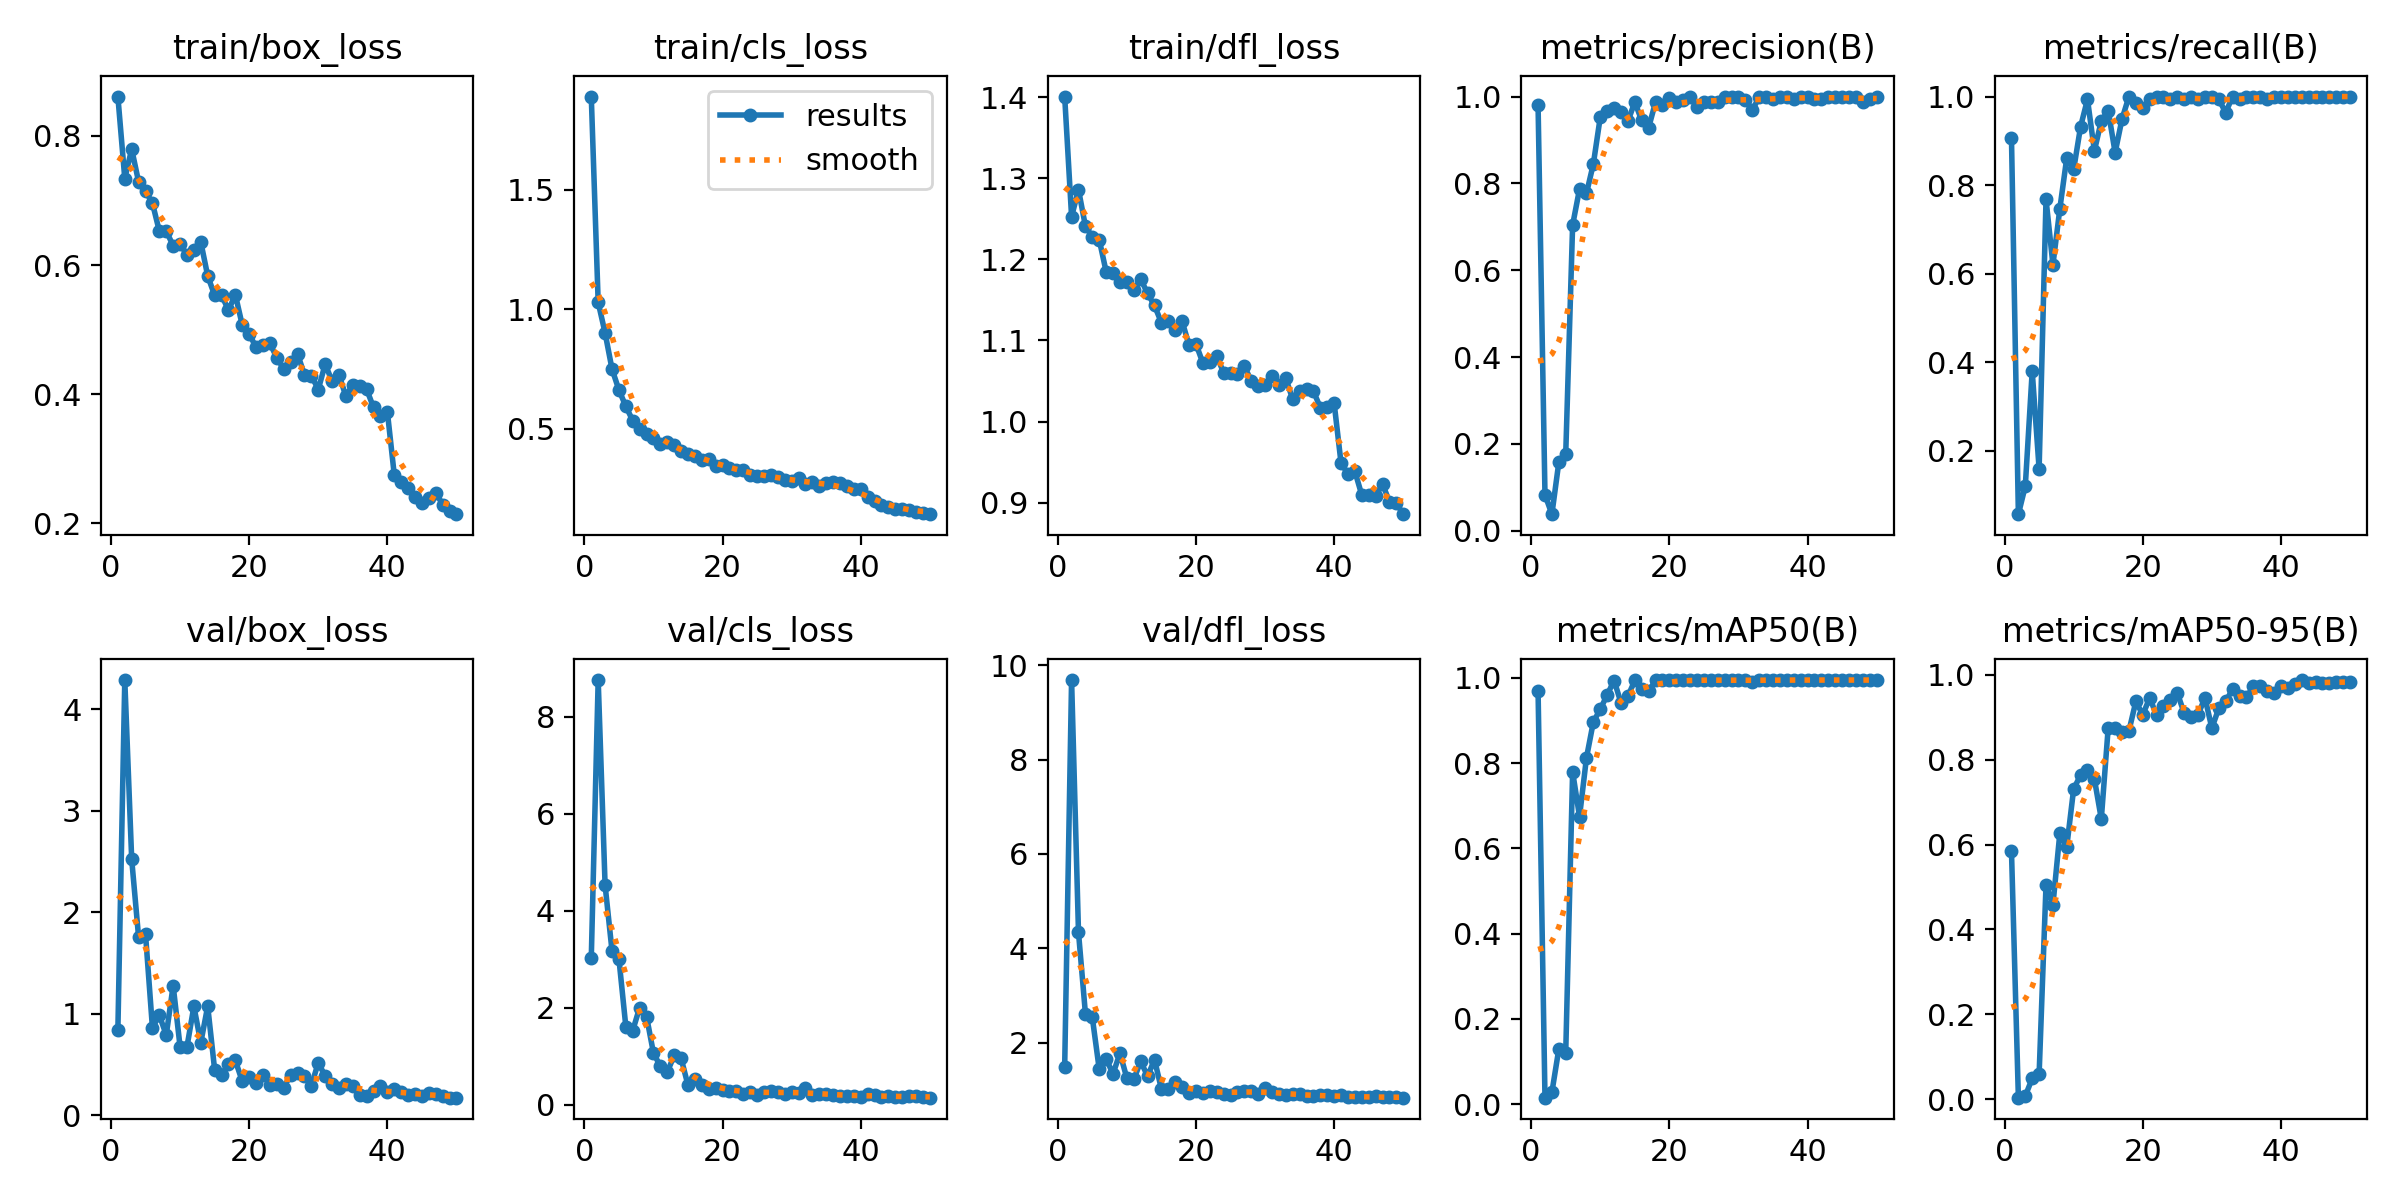

confusion_matrix.png


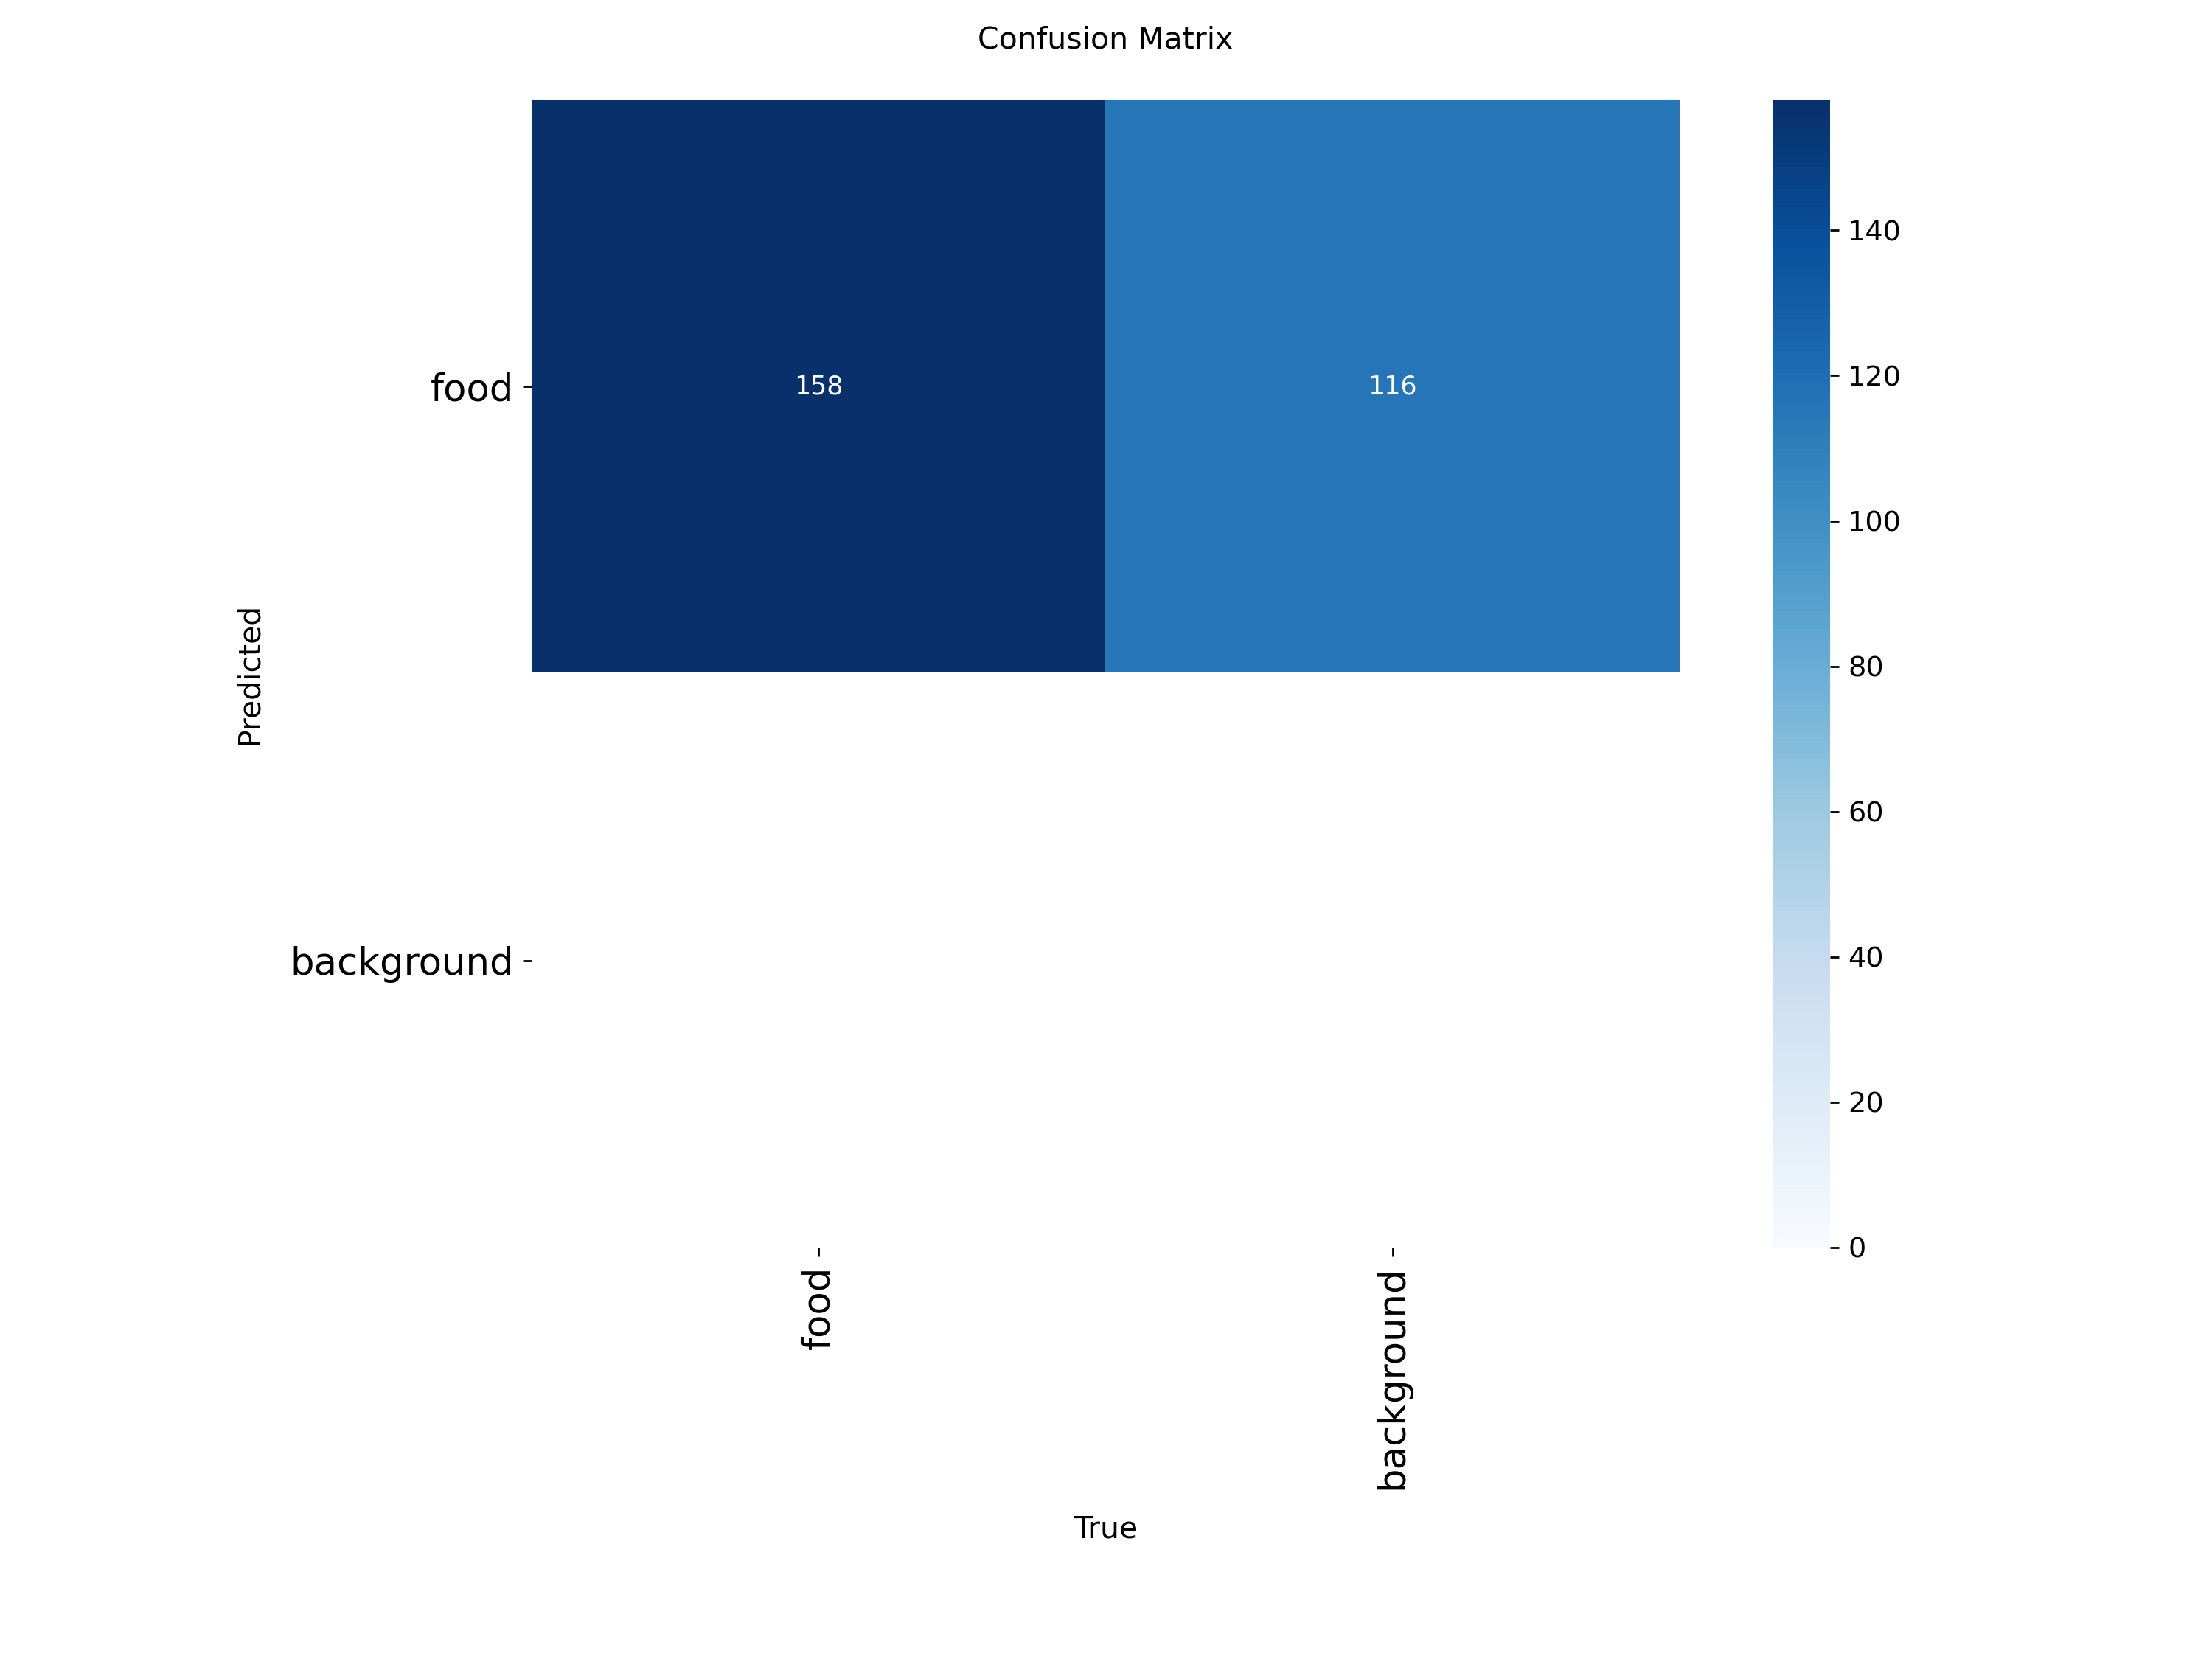

confusion_matrix_normalized.png


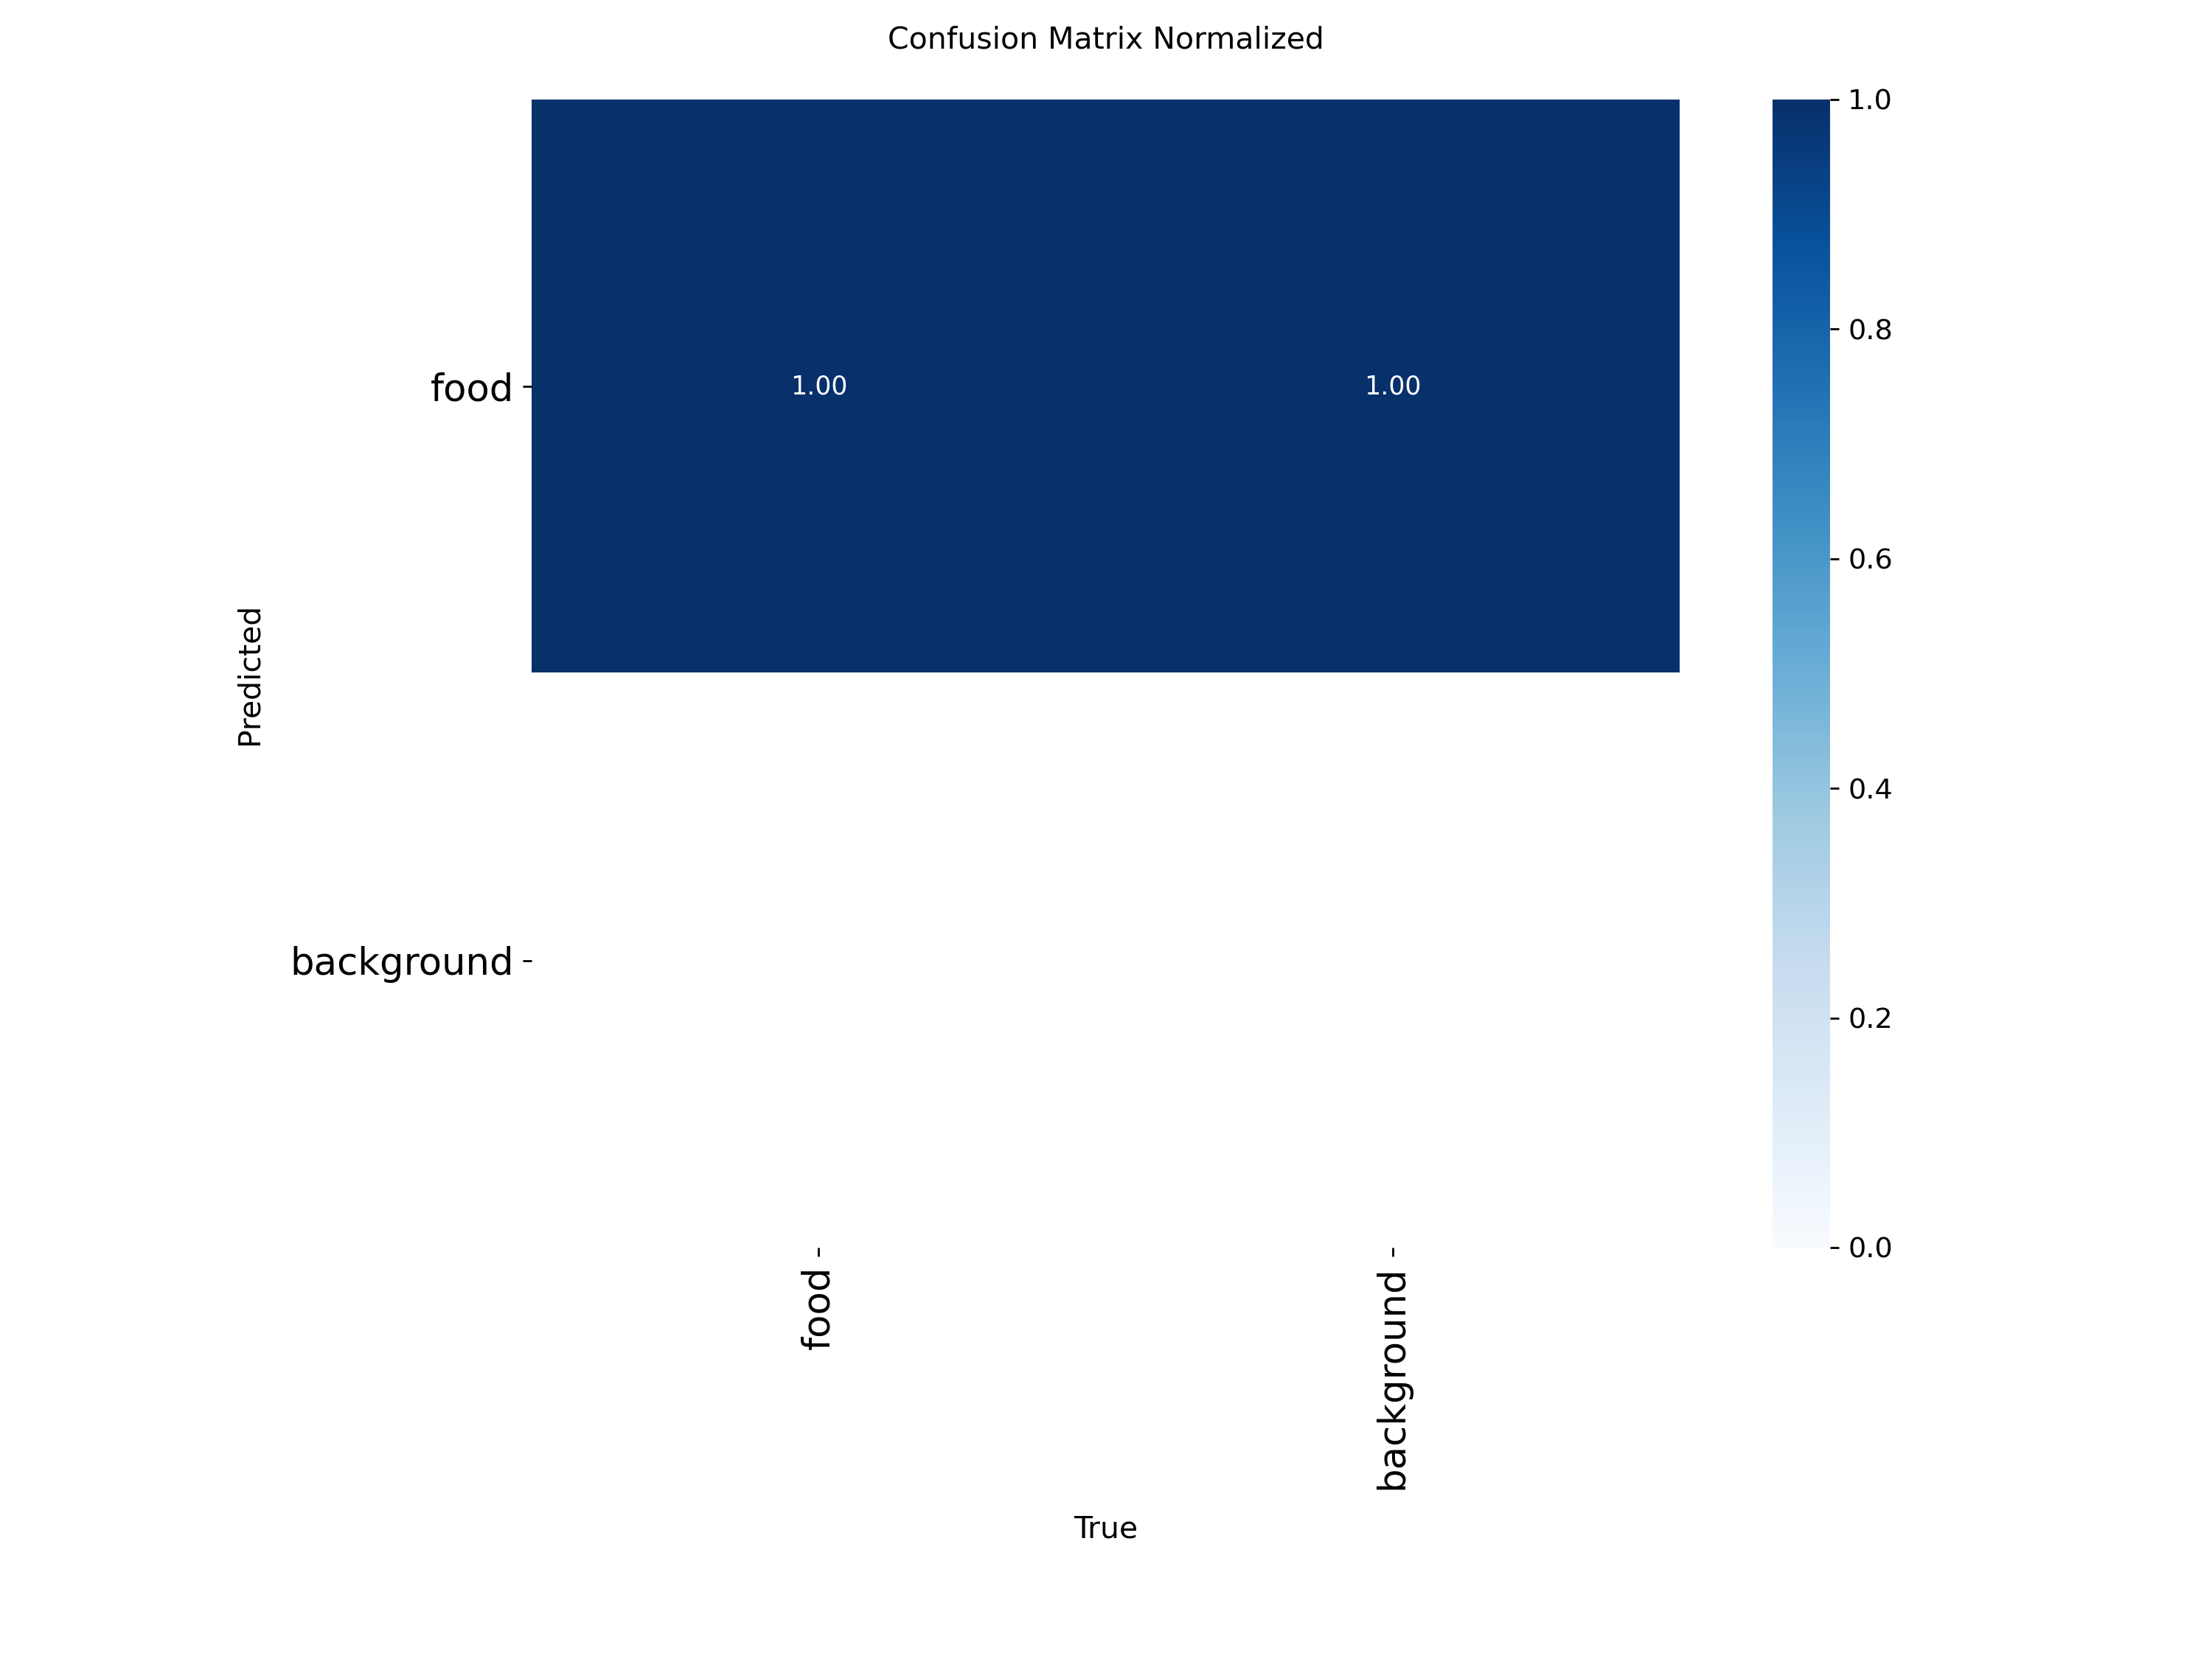

In [16]:
from IPython.display import Image as DisplayImage
from IPython.display import display

report_files = [
    RUN_DIR / "results.png",
    RUN_DIR / "confusion_matrix.png",
    RUN_DIR / "confusion_matrix_normalized.png",
    RUN_DIR / "PR_curve.png",
    RUN_DIR / "F1_curve.png",
]

for report_path in report_files:
    if report_path.is_file():
        print(report_path.name)
        display(DisplayImage(filename=str(report_path)))


## 14. 최종 결과 확인

학습 완료 후 다음 파일을 사용하면 됩니다.

```text
MyDrive/training/yolo_food_detection/runs/<RUN_NAME>/weights/best.pt
```

`best.pt`가 최종 음식 위치 탐지 모델입니다.


In [17]:
print("===== 최종 산출물 =====")
print("학습 결과:", RUN_DIR)
print("최종 모델:", BEST_WEIGHTS)
print("마지막 Epoch 모델:", LAST_WEIGHTS)
print("검증 지표:", METRICS_PATH)
print("예측 결과:", PREDICT_DIR)

assert BEST_WEIGHTS.exists()
assert METRICS_PATH.exists()

print("\n모든 작업이 완료되었습니다.")


===== 최종 산출물 =====
학습 결과: /content/drive/MyDrive/final_1_team/apps/api/food-image-cleanup-pipeline/data/training/yolo_food_detection/runs/yolo11n_food_20260721_070809
최종 모델: /content/drive/MyDrive/final_1_team/apps/api/food-image-cleanup-pipeline/data/training/yolo_food_detection/runs/yolo11n_food_20260721_070809/weights/best.pt
마지막 Epoch 모델: /content/drive/MyDrive/final_1_team/apps/api/food-image-cleanup-pipeline/data/training/yolo_food_detection/runs/yolo11n_food_20260721_070809/weights/last.pt
검증 지표: /content/drive/MyDrive/final_1_team/apps/api/food-image-cleanup-pipeline/data/training/yolo_food_detection/runs/yolo11n_food_20260721_070809/validation_metrics.json
예측 결과: /content/drive/MyDrive/final_1_team/apps/api/food-image-cleanup-pipeline/data/training/yolo_food_detection/runs/predictions/yolo11n_food_20260721_070809

모든 작업이 완료되었습니다.


## 15. 중단된 학습 재개 — 선택 실행

학습이 중단됐고 `last.pt`가 남아 있을 때만 실행하세요.

```python
from ultralytics import YOLO

resume_model = YOLO(
    "/content/drive/MyDrive/training/yolo_food_detection/runs/"
    "<기존_RUN_NAME>/weights/last.pt"
)

resume_model.train(resume=True)
```

`<기존_RUN_NAME>`을 실제 폴더명으로 변경해야 합니다.
